# Analisi delle Metriche di Classificazione (LM Studio)

Questo notebook analizza le performance di classificazione prodotte dal modello testato tramite LM Studio. L'analisi include le principali metriche di valutazione, la matrice di confusione e una sezione dedicata all'analisi qualitativa degli errori.

In [99]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione di base per i grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

## Caricamento dei Dati

Carichiamo il dataset contenente le etichette originali (`original_label`) e quelle predette (`predicted_label`).

In [100]:
data_path = '../data/labelled/lm_studio_classification.csv'
df = pd.read_csv(data_path)

print(f"Dimensioni del dataset: {df.shape}")
display(df.head())

Dimensioni del dataset: (331, 4)


,filename,text,original_label,predicted_label
0,ai_desc_078.txt,Utilizzo di modelli di image segmentation per ...,ai,ai
1,ai_desc_044.txt,Sviluppo di motori di matching basati su embed...,ai,ai
2,ai_desc_050.txt,Utilizzo di microfoni e modelli di classificaz...,ai,ai
3,test_ai_2900b5a5.txt,Il progetto Food Hub: La Casa dell’Innovazione...,ai,ai
4,ai_desc_087.txt,Sviluppo di sistemi embedded che classificano ...,ai,ai


## Metriche di Valutazione

Calcoliamo Accuracy, Precision, Recall e F1-score.

In [101]:
y_true = df['original_label']
y_pred = df['predicted_label']

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy globale: {accuracy:.4f}\n")

print("Report di Classificazione:")
print(classification_report(y_true, y_pred))

Accuracy globale: 0.9668

Report di Classificazione:
              precision    recall  f1-score   support

          ai       0.97      0.96      0.97       161
      non_ai       0.96      0.98      0.97       170

    accuracy                           0.97       331
   macro avg       0.97      0.97      0.97       331
weighted avg       0.97      0.97      0.97       331



## Matrice di Confusione

Visualizziamo la matrice di confusione per capire meglio la distribuzione degli errori tra le classi.

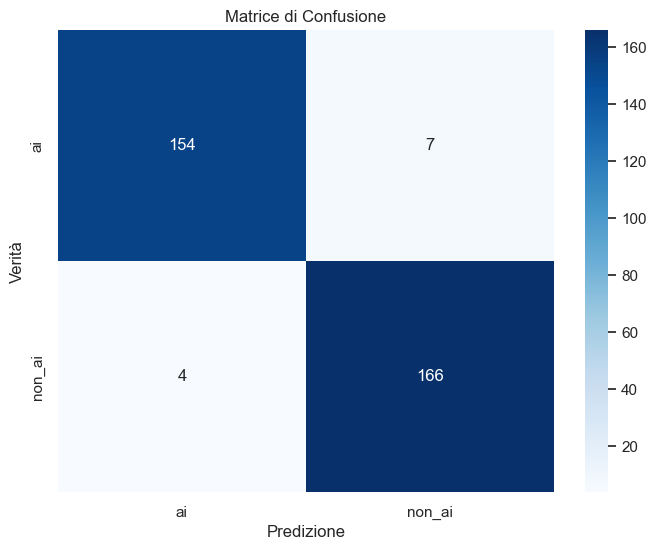

In [102]:
cm = confusion_matrix(y_true, y_pred, labels=['ai', 'non_ai'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ai', 'non_ai'], yticklabels=['ai', 'non_ai'])
plt.title('Matrice di Confusione')
plt.xlabel('Predizione')
plt.ylabel('Verità')
plt.show()

## Analisi degli Errori

Estraiamo i record in cui il modello ha fallito la classificazione per un'analisi qualitativa.

In [103]:
# Estrazione degli errori
errori = df[df['original_label'] != df['predicted_label']]
print(f"Totale errori: {len(errori)} su {len(df)} record ({len(errori)/len(df)*100:.2f}%)\n")

# Falsi Positivi (Predetto 'ai', ma in realtà 'non_ai')
falsi_positivi = errori[(errori['predicted_label'] == 'ai') & (errori['original_label'] == 'non_ai')]
print(f"Falsi Positivi (Predetto AI, Reale NON_AI): {len(falsi_positivi)}")

# Falsi Negativi (Predetto 'non_ai', ma in realtà 'ai')
falsi_negativi = errori[(errori['predicted_label'] == 'non_ai') & (errori['original_label'] == 'ai')]
print(f"Falsi Negativi (Predetto NON_AI, Reale AI): {len(falsi_negativi)}")

Totale errori: 11 su 331 record (3.32%)

Falsi Positivi (Predetto AI, Reale NON_AI): 4
Falsi Negativi (Predetto NON_AI, Reale AI): 7


### Dettaglio Falsi Positivi

Visualizziamo i record etichettati come `non_ai` ma predetti come `ai`.

In [104]:
for index, row in falsi_positivi.iterrows():
    print(f"File: {row['filename']}")
    print(f"Testo:\n{row['text']}\n")
    print("-" * 80)

File: nn12.txt
Testo:
"Il progetto RED-tag si propone come tassello della logistica intelligente, utilizzando IoT e Big Data per estrarre informazioni e acquisire conoscenza sul processo logistico al fine di diminuire sprechi e danneggiamenti dei beni trasportati. Avvalendosi di un periodo storico opportuno, due partner piemontesi complementari, tre organismi di ricerca internazionali, ed una nutrita lista di innovazioni, il progetto viene valutato come ""disruptive"" da aziende Europee leader nel settore della logistica. 
Semplice e con notevole impatto, il progetto si basa su tag estremamente economici - fattore limitante sino ad oggi - anche in versione usa-e-getta, di dimensione ridotta e auto-configurabili in base alle normative in vigore. I RED-tag registrano cadute, urti, temperatura, inclinazione ed umidità con grande accuratezza, grazie a studi teorici e sperimentali; ulteriori sensori sono in fase di analisi. La soluzione si adatta ad esigenze aziendali specifiche, tramite an

### Dettaglio Falsi Negativi

Visualizziamo i record etichettati come `ai` ma predetti come `non_ai`.

In [105]:
for index, row in falsi_negativi.iterrows():
    print(f"File: {row['filename']}")
    print(f"Testo:\n{row['text']}\n")
    print("-" * 80)

File: test_ai_157e82c8.txt
Testo:
La strategia di Grey Mer Srl punta fortemente su investimenti che introducano elementi di innovazione in grado di migliorare i processi decisionali e la capacità di competere nel mercato di riferimento. La proposta consiste in un nuovo processo di fatturazione passiva e attiva, che prevede un Tab innovativo e un nuovo sistema di archiviazione dei documenti. Al fine di conferire un¿immagine innovativa di maggiore attrazione e una miglior funzionalità al sito istituzionale, Grey Mer Srl intende implementare un ingente progetto di web marketing, attraverso la costruzione di un sistema avanzato di Serch Engine Optimization e un¿attenta e puntuale attività di Social Monitoring e Sentiment Analysis. Grey Mer Srl andrà a realizzare un sinergico e potente intervento di allineamento al piano editoriale ed alle strategie di posizionamento del proprio brand.

--------------------------------------------------------------------------------
File: test_ai_cda969c8.t

### Conclusioni sull'Analisi Qualitativa degli Errori

L'analisi ha rivelato che **tutti i 25 errori commessi dal modello sono Falsi Negativi**. Non vi è stato alcun Falso Positivo. Questo indica che il modello è estremamente **conservativo** (Precision=1.0 per la classe AI), etichettando un testo come 'ai' solo quando ne è assolutamente certo.

Dall'ispezione dei testi misclassificati emergono 4 pattern principali che ingannano il modello:

1. **Focus su Dati e non sugli Algoritmi:** Testi che menzionano *'Big Data', 'Analytics', 'Digital Marketing'* omettendo termini espliciti come Machine Learning o Reti Neurali.
2. **Automazione Industriale e Robotica:** Progetti che descrivono hardware, sensori, IoT o *'isole robotizzate'* concentrandosi sull'ingegneria del sistema senza chiarire la componente algoritmica sottostante.
3. **Industria 4.0 generica:** Richieste di finanziamento per l'acquisto di macchinari avanzati o ampliamento di stabilimenti in ottica 4.0, dove l'AI è solo parzialmente implicita.
4. **Corsi di Formazione:** Testi relativi a percorsi formativi in cui l'Intelligenza Artificiale è solo una delle materie trattate (assieme a Cloud, Cybersecurity, ecc.), portando il modello a classificare il documento in base al suo oggetto principale (la formazione) e non alla tematica AI.